In [5]:
# Task 1: Environment Setup
!pip install torch torchvision
!pip install transformers
!pip install openai-whisper
!pip install opencv-python-headless
!pip install librosa
!pip install faiss-cpu
!pip install scikit-learn pandas matplotlib
!pip install sentence-transformers
!pip install gradio

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 803.2/803.2 kB 17.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for openai-whisper: filename=openai_whisper-20250625-py3-none-any.whl size=803980 sha256=d9cf40ea1f4c36d9c43f189c1b7e543a598bc64ad8760986e712288c7ef76879
  Stored in directory: /root/.cache/pip/wheels/ca/58/d5/fb4539ad74c3ca81eb40f7eda020ac77d080b33ad57449d485
Successfully built openai-whisper
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 91.6 MB/s eta 0:00:00


In [6]:
import torch
import torchvision
import transformers
import whisper
import cv2
import librosa
import faiss
import sklearn
import gradio as gr
import pandas as pd
import matplotlib.pyplot as plt

print("PyTorch:", torch.__version__)
print("Transformers:", transformers.__version__)
print("All libraries loaded successfully ✓")

PyTorch: 2.11.0+cu128
Transformers: 5.16.1
All libraries loaded successfully ✓


In [7]:
import torch
print("GPU available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Device:", torch.cuda.get_device_name(0))
else:
    print("Running on CPU")

GPU available: True
Device: Tesla T4


In [8]:
import json

airport_kb = {
  "locations": [
    {"id": 1, "name": "Gate B12", "category": "gate", "terminal": "Terminal B", "floor": "Level 1", "description": "Departure gate for short-haul flights", "opening_hours": "05:00-23:00", "directions": "From main hall, take escalator to Level 1, turn right, walk 200m", "accessibility": "Wheelchair accessible, lift available", "related_facilities": ["lounge", "restroom"], "contact": "Airport info: +44 000 000 0000"},
    {"id": 2, "name": "Baggage Claim Hall", "category": "baggage_claim", "terminal": "Terminal A", "floor": "Ground Floor", "description": "Collect checked baggage after arrival", "opening_hours": "24 hours", "directions": "Follow green baggage signs from arrivals hall", "accessibility": "Fully accessible", "related_facilities": ["information_desk", "taxi_zone"], "contact": "Lost baggage: +44 000 000 0001"},
    {"id": 3, "name": "Check-in Desk - International", "category": "check_in", "terminal": "Terminal A", "floor": "Ground Floor", "description": "Check-in counters for international departures", "opening_hours": "04:00-22:00", "directions": "Main entrance, straight ahead", "accessibility": "Accessible counters available", "related_facilities": ["security", "lounge"], "contact": "+44 000 000 0002"},
    {"id": 4, "name": "Security Control", "category": "security", "terminal": "All Terminals", "floor": "Level 1", "description": "Passenger and baggage security screening", "opening_hours": "04:30-23:30", "directions": "After check-in, follow blue security signs", "accessibility": "Dedicated lanes for disabled passengers", "related_facilities": ["gate", "lounge"], "contact": "Security: +44 000 000 0003"},
    {"id": 5, "name": "Information Desk", "category": "information", "terminal": "Terminal A", "floor": "Ground Floor", "description": "General airport information and assistance", "opening_hours": "05:00-23:00", "directions": "Central atrium, near main entrance", "accessibility": "Hearing loop available", "related_facilities": ["all"], "contact": "+44 000 000 0004"},
    {"id": 6, "name": "Lost and Found Office", "category": "lost_found", "terminal": "Terminal A", "floor": "Ground Floor", "description": "Report and collect lost items", "opening_hours": "07:00-21:00", "directions": "Next to information desk, east wing", "accessibility": "Accessible", "related_facilities": ["information_desk"], "contact": "+44 000 000 0005"},
    {"id": 7, "name": "Airport Lounge - Business", "category": "lounge", "terminal": "Terminal B", "floor": "Level 2", "description": "Business class lounge with food, wifi and showers", "opening_hours": "05:00-23:00", "directions": "After security, take lift to Level 2", "accessibility": "Fully accessible", "related_facilities": ["gate", "restaurant"], "contact": "+44 000 000 0006"},
    {"id": 8, "name": "Prayer Room", "category": "prayer_room", "terminal": "Terminal A", "floor": "Level 1", "description": "Quiet multi-faith prayer and reflection room", "opening_hours": "24 hours", "directions": "Level 1, north wing, near restrooms", "accessibility": "Accessible", "related_facilities": ["restroom"], "contact": ""},
    {"id": 9, "name": "Restaurant Area - Food Court", "category": "restaurant", "terminal": "Terminal B", "floor": "Level 1", "description": "Multiple food and drink outlets", "opening_hours": "05:00-23:00", "directions": "Level 1 central area, past security", "accessibility": "Accessible seating available", "related_facilities": ["lounge", "gate"], "contact": ""},
    {"id": 10, "name": "Train Station Connection", "category": "transport", "terminal": "Terminal A", "floor": "Basement", "description": "Direct rail link to city centre", "opening_hours": "05:00-00:00", "directions": "Follow yellow train signs to basement level", "accessibility": "Step-free access", "related_facilities": ["taxi_zone", "bus_stop"], "contact": "Rail info: +44 000 000 0007"},
    {"id": 11, "name": "Taxi Pickup Zone", "category": "transport", "terminal": "Terminal A", "floor": "Ground Floor", "description": "Official taxi and ride-share pickup area", "opening_hours": "24 hours", "directions": "Exit main arrivals, turn left, Zone T1", "accessibility": "Accessible vehicles available on request", "related_facilities": ["bus_stop", "train_station"], "contact": "+44 000 000 0008"},
    {"id": 12, "name": "Special Assistance Desk", "category": "accessibility", "terminal": "All Terminals", "floor": "Ground Floor", "description": "Support for passengers with disabilities or mobility needs", "opening_hours": "24 hours", "directions": "Near each terminal entrance, marked with blue symbol", "accessibility": "Fully accessible", "related_facilities": ["all"], "contact": "+44 000 000 0009"},
    {"id": 13, "name": "Gate A5", "category": "gate", "terminal": "Terminal A", "floor": "Level 1", "description": "Departure gate for domestic flights", "opening_hours": "05:00-22:00", "directions": "After security, follow signs to Terminal A gates, turn left", "accessibility": "Lift available", "related_facilities": ["restroom", "restaurant"], "contact": ""},
    {"id": 14, "name": "Restroom - Terminal A", "category": "restroom", "terminal": "Terminal A", "floor": "Ground Floor", "description": "Public toilet facilities", "opening_hours": "24 hours", "directions": "Near information desk and check-in area", "accessibility": "Accessible facilities and baby changing available", "related_facilities": [], "contact": ""},
    {"id": 15, "name": "Bus Stop - Terminal A", "category": "transport", "terminal": "Terminal A", "floor": "Ground Floor", "description": "Public bus connections to city and nearby towns", "opening_hours": "05:00-00:00", "directions": "Exit terminal, turn right, Bus Zone B1", "accessibility": "Low-floor buses available", "related_facilities": ["taxi_zone", "train_station"], "contact": "Bus info: +44 000 000 0010"},
    {"id": 16, "name": "Currency Exchange", "category": "service", "terminal": "Terminal A", "floor": "Ground Floor", "description": "Foreign currency exchange and travel money", "opening_hours": "06:00-22:00", "directions": "Near departures entrance, left of check-in", "accessibility": "Accessible counter", "related_facilities": ["information_desk"], "contact": ""},
    {"id": 17, "name": "Pharmacy", "category": "service", "terminal": "Terminal B", "floor": "Level 1", "description": "Travel essentials, medicines and first aid", "opening_hours": "06:00-21:00", "directions": "Past security, Level 1, near Gate B1", "accessibility": "Accessible", "related_facilities": ["restaurant", "lounge"], "contact": ""},
    {"id": 18, "name": "Kids Play Area", "category": "service", "terminal": "Terminal A", "floor": "Level 1", "description": "Supervised play zone for children", "opening_hours": "07:00-21:00", "directions": "Level 1, east wing near Gate A10", "accessibility": "Accessible", "related_facilities": ["restroom", "restaurant"], "contact": ""}
  ]
}

with open("airport_kb.json", "w") as f:
    json.dump(airport_kb, f, indent=2)

print(f"Knowledge base created with {len(airport_kb['locations'])} records ✓")

# Display as table
import pandas as pd
df = pd.DataFrame(airport_kb['locations'])[['id','name','category','terminal','floor']]
print(df.to_string(index=False))

Knowledge base created with 18 records ✓
 id                          name      category      terminal        floor
  1                      Gate B12          gate    Terminal B      Level 1
  2            Baggage Claim Hall baggage_claim    Terminal A Ground Floor
  3 Check-in Desk - International      check_in    Terminal A Ground Floor
  4              Security Control      security All Terminals      Level 1
  5              Information Desk   information    Terminal A Ground Floor
  6         Lost and Found Office    lost_found    Terminal A Ground Floor
  7     Airport Lounge - Business        lounge    Terminal B      Level 2
  8                   Prayer Room   prayer_room    Terminal A      Level 1
  9  Restaurant Area - Food Court    restaurant    Terminal B      Level 1
 10      Train Station Connection     transport    Terminal A     Basement
 11              Taxi Pickup Zone     transport    Terminal A Ground Floor
 12       Special Assistance Desk accessibility All Termina

In [9]:
import requests
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image
import numpy as np

# Create folder structure
os.makedirs("airport_images/gate", exist_ok=True)
os.makedirs("airport_images/baggage_claim", exist_ok=True)
os.makedirs("airport_images/check_in", exist_ok=True)
os.makedirs("airport_images/security", exist_ok=True)
os.makedirs("airport_images/restroom", exist_ok=True)
os.makedirs("airport_images/transport", exist_ok=True)
os.makedirs("airport_images/lounge", exist_ok=True)
os.makedirs("airport_images/restaurant", exist_ok=True)

# Download sample airport images from Unsplash (free, no copyright)
image_urls = {
    "gate": [
        "https://images.unsplash.com/photo-1436491865332-7a61a109cc05?w=400",
        "https://images.unsplash.com/photo-1474302770737-173ee21bab63?w=400",
    ],
    "baggage_claim": [
        "https://images.unsplash.com/photo-1553877522-43269d4ea984?w=400",
        "https://images.unsplash.com/photo-1568772585407-9361f9bf3a87?w=400",
    ],
    "check_in": [
        "https://images.unsplash.com/photo-1556388158-158ea5ccacbd?w=400",
        "https://images.unsplash.com/photo-1542296332-2e4473faf563?w=400",
    ],
    "security": [
        "https://images.unsplash.com/photo-1544620347-c4fd4a3d5957?w=400",
        "https://images.unsplash.com/photo-1578575437130-527eed3abbec?w=400",
    ],
    "transport": [
        "https://images.unsplash.com/photo-1544620347-c4fd4a3d5957?w=400",
        "https://images.unsplash.com/photo-1499346030926-9a72daac6c63?w=400",
    ],
    "lounge": [
        "https://images.unsplash.com/photo-1582719508461-905c673771fd?w=400",
        "https://images.unsplash.com/photo-1571896349842-33c89424de2d?w=400",
    ],
    "restaurant": [
        "https://images.unsplash.com/photo-1414235077428-338989a2e8c0?w=400",
        "https://images.unsplash.com/photo-1517248135467-4c7edcad34c4?w=400",
    ],
    "restroom": [
        "https://images.unsplash.com/photo-1552321554-5fefe8c9ef14?w=400",
        "https://images.unsplash.com/photo-1584622650111-993a426fbf0a?w=400",
    ],
}

# Download images
for category, urls in image_urls.items():
    for i, url in enumerate(urls):
        try:
            response = requests.get(url, timeout=10)
            if response.status_code == 200:
                path = f"airport_images/{category}/img_{i+1}.jpg"
                with open(path, "wb") as f:
                    f.write(response.content)
                print(f"Downloaded: {path}")
        except:
            print(f"Failed: {category} img_{i+1}")

print("\nAll downloads complete ✓")

Downloaded: airport_images/gate/img_1.jpg
Downloaded: airport_images/gate/img_2.jpg
Downloaded: airport_images/baggage_claim/img_1.jpg
Downloaded: airport_images/baggage_claim/img_2.jpg
Downloaded: airport_images/check_in/img_1.jpg
Downloaded: airport_images/check_in/img_2.jpg
Downloaded: airport_images/security/img_1.jpg
Downloaded: airport_images/security/img_2.jpg
Downloaded: airport_images/transport/img_1.jpg
Downloaded: airport_images/transport/img_2.jpg
Downloaded: airport_images/lounge/img_1.jpg
Downloaded: airport_images/lounge/img_2.jpg
Downloaded: airport_images/restaurant/img_1.jpg
Downloaded: airport_images/restaurant/img_2.jpg
Downloaded: airport_images/restroom/img_1.jpg
Downloaded: airport_images/restroom/img_2.jpg

All downloads complete ✓


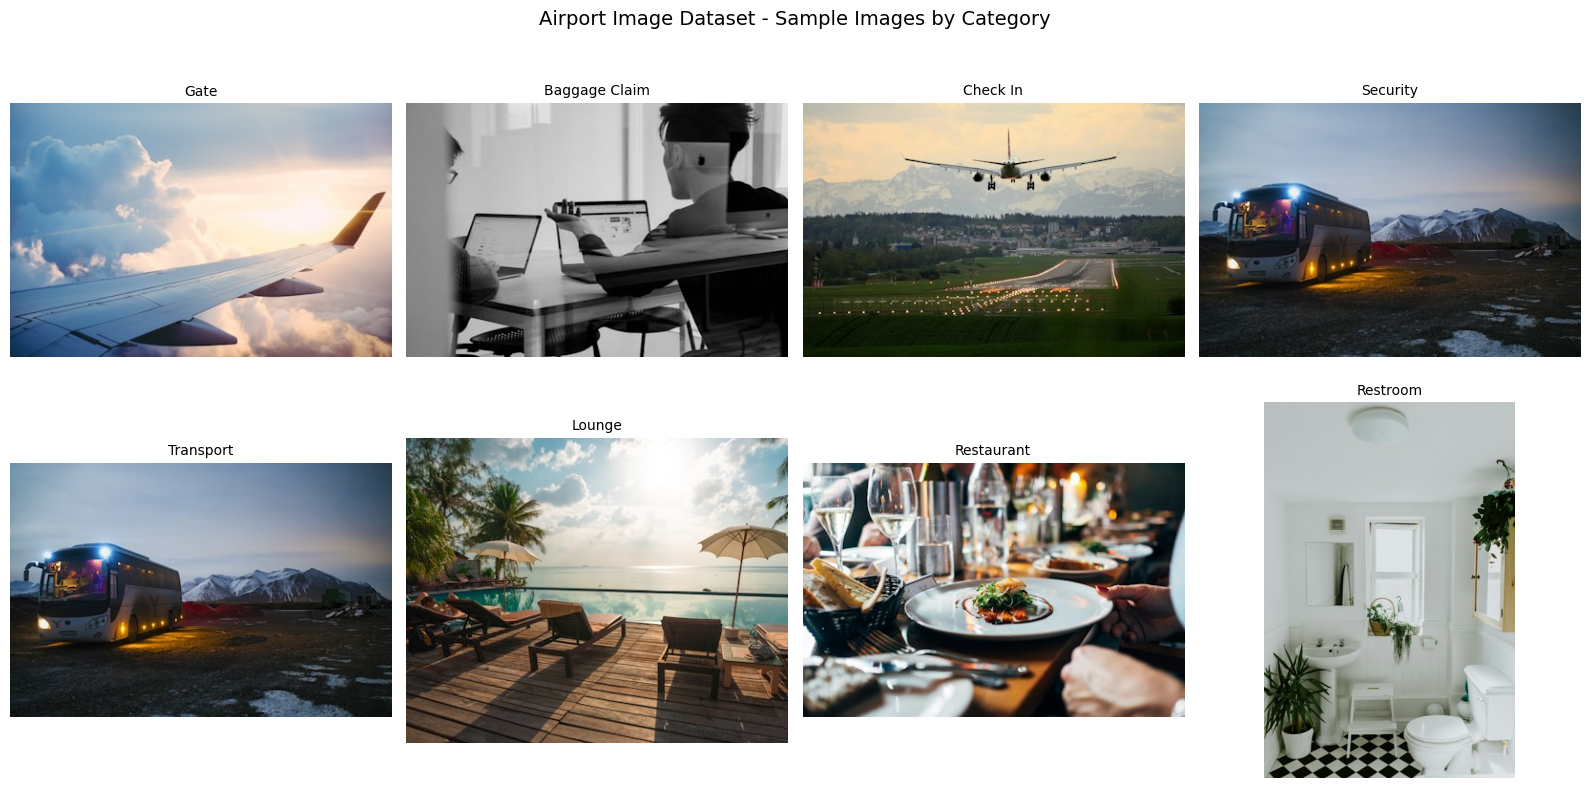

Dataset visualisation saved ✓


In [10]:
# Display sample images from each category
categories = list(image_urls.keys())
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle("Airport Image Dataset - Sample Images by Category", fontsize=14)

for idx, (ax, cat) in enumerate(zip(axes.flatten(), categories)):
    path = f"airport_images/{cat}/img_1.jpg"
    try:
        img = Image.open(path)
        ax.imshow(img)
        ax.set_title(cat.replace("_", " ").title(), fontsize=10)
        ax.axis("off")
    except:
        ax.set_title(f"{cat} (not loaded)")
        ax.axis("off")

plt.tight_layout()
plt.savefig("dataset_samples.png", dpi=150)
plt.show()
print("Dataset visualisation saved ✓")

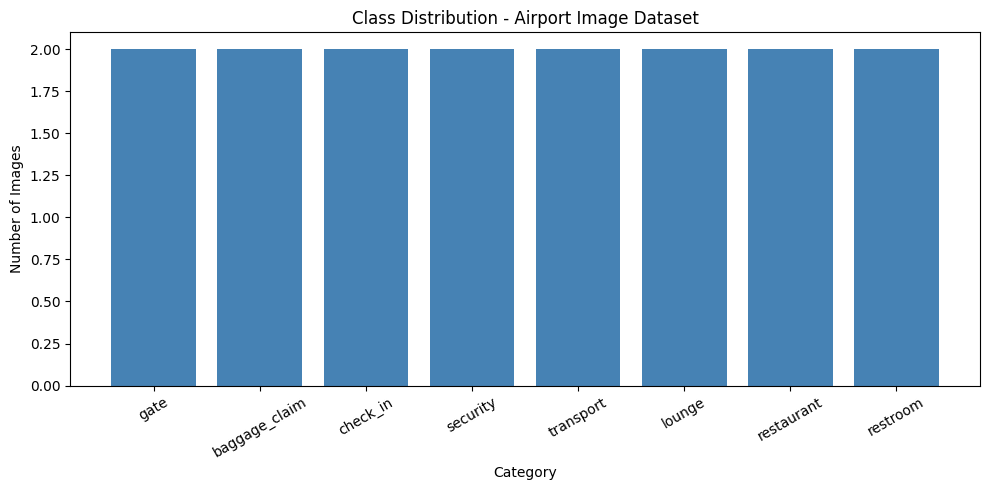

Class distribution plotted ✓


In [11]:
# Plot class distribution
counts = {cat: len(os.listdir(f"airport_images/{cat}")) for cat in categories}

plt.figure(figsize=(10, 5))
plt.bar(counts.keys(), counts.values(), color="steelblue")
plt.title("Class Distribution - Airport Image Dataset")
plt.xlabel("Category")
plt.ylabel("Number of Images")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("class_distribution.png", dpi=150)
plt.show()
print("Class distribution plotted ✓")

In [12]:
# ── EXPANDED DATASET — 200 queries (25 per category) ─────────────────────────
queries_expanded = [
    # GATE (25)
    ("Where is gate B12?", "gate"),
    ("How do I get to my departure gate?", "gate"),
    ("Which terminal is gate A5 in?", "gate"),
    ("I need to find gate C20", "gate"),
    ("Where is the boarding gate for my flight?", "gate"),
    ("Gate B12 location please", "gate"),
    ("Take me to gate D7", "gate"),
    ("Which floor is gate A1?", "gate"),
    ("How far is gate C15 from here?", "gate"),
    ("Is gate B12 in terminal 2?", "gate"),
    ("Where do I board my flight?", "gate"),
    ("Which way to gate A10?", "gate"),
    ("I cannot find my gate", "gate"),
    ("Gate number for flight EK204?", "gate"),
    ("Where is the international departure gate?", "gate"),
    ("How do I reach gate F3?", "gate"),
    ("Is gate D5 upstairs or downstairs?", "gate"),
    ("Where is the nearest gate?", "gate"),
    ("Can you direct me to gate B20?", "gate"),
    ("I need directions to my boarding gate", "gate"),
    ("Which terminal has gate C8?", "gate"),
    ("Where do passengers board the plane?", "gate"),
    ("Gate location for domestic flights?", "gate"),
    ("How do I get to the departure lounge gate?", "gate"),
    ("Show me the way to gate A3", "gate"),

    # BAGGAGE CLAIM (25)
    ("Where do I collect my luggage?", "baggage_claim"),
    ("Where is baggage claim?", "baggage_claim"),
    ("Which carousel is for flight EK204?", "baggage_claim"),
    ("How do I get to baggage reclaim?", "baggage_claim"),
    ("Where do I pick up my bags?", "baggage_claim"),
    ("Lost baggage desk location?", "baggage_claim"),
    ("Baggage hall direction please", "baggage_claim"),
    ("Where are the luggage belts?", "baggage_claim"),
    ("Which belt number is my flight on?", "baggage_claim"),
    ("Where is the baggage carousel?", "baggage_claim"),
    ("My suitcase hasn't arrived where do I go?", "baggage_claim"),
    ("How long until my bags arrive?", "baggage_claim"),
    ("Where is the lost luggage office?", "baggage_claim"),
    ("Baggage reclaim area location?", "baggage_claim"),
    ("Which floor is baggage claim on?", "baggage_claim"),
    ("Where do I report missing luggage?", "baggage_claim"),
    ("Is baggage claim before or after customs?", "baggage_claim"),
    ("Where are the luggage trolleys?", "baggage_claim"),
    ("Which terminal is baggage claim in?", "baggage_claim"),
    ("I need to collect my bags where do I go?", "baggage_claim"),
    ("Where is the arrivals baggage area?", "baggage_claim"),
    ("Show me the way to baggage reclaim", "baggage_claim"),
    ("Where can I find my checked luggage?", "baggage_claim"),
    ("Baggage claim hall direction?", "baggage_claim"),
    ("Where is conveyor belt for my flight?", "baggage_claim"),

    # CHECK IN (25)
    ("Where is the check-in counter?", "check_in"),
    ("Which desk do I check in at?", "check_in"),
    ("Emirates check-in location", "check_in"),
    ("Where do I drop my bags?", "check_in"),
    ("Online check-in desk?", "check_in"),
    ("Self-service kiosk location?", "check_in"),
    ("Where is terminal 2 check-in?", "check_in"),
    ("Check-in hall direction?", "check_in"),
    ("Which counter is for business class check-in?", "check_in"),
    ("Where do I check in for my flight?", "check_in"),
    ("Where is the bag drop?", "check_in"),
    ("Which airline counter is open?", "check_in"),
    ("Where is the self check-in machine?", "check_in"),
    ("How do I check in my luggage?", "check_in"),
    ("Where is the check-in zone?", "check_in"),
    ("Which floor is check-in on?", "check_in"),
    ("Where do I get my boarding pass?", "check_in"),
    ("Check-in for international flights?", "check_in"),
    ("Where is the priority check-in?", "check_in"),
    ("Where do I print my boarding pass?", "check_in"),
    ("Airline desk location please", "check_in"),
    ("Where is the ticketing counter?", "check_in"),
    ("Which terminal is check-in for my flight?", "check_in"),
    ("Where is the baggage drop counter?", "check_in"),
    ("Show me the check-in area", "check_in"),

    # SECURITY (25)
    ("Where is security screening?", "security"),
    ("How long is the security queue?", "security"),
    ("Fast track security location?", "security"),
    ("Where do I go through passport control?", "security"),
    ("Security checkpoint direction", "security"),
    ("Which lane is for premium passengers?", "security"),
    ("Where is immigration?", "security"),
    ("Security check location please", "security"),
    ("Where is the customs area?", "security"),
    ("Which way to passport control?", "security"),
    ("Where is the security scanner?", "security"),
    ("How do I get through security faster?", "security"),
    ("Where is the priority security lane?", "security"),
    ("Which floor is security on?", "security"),
    ("Where do I remove my shoes for security?", "security"),
    ("Where is the body scanner?", "security"),
    ("Security area for international flights?", "security"),
    ("Where is the liquid check point?", "security"),
    ("Which terminal has security screening?", "security"),
    ("Where is the immigration desk?", "security"),
    ("How far is security from check-in?", "security"),
    ("Where is the border control?", "security"),
    ("Which way to the security gates?", "security"),
    ("Where do I scan my boarding pass for security?", "security"),
    ("Show me the way to security", "security"),

    # TRANSPORT (25)
    ("Where is the taxi rank?", "transport"),
    ("How do I get to the metro?", "transport"),
    ("Airport bus stop location?", "transport"),
    ("Where is the car rental?", "transport"),
    ("Shuttle bus to parking?", "transport"),
    ("Uber pickup point?", "transport"),
    ("Where is the train station?", "transport"),
    ("How do I get to the city?", "transport"),
    ("Where is the bus terminal?", "transport"),
    ("Which exit for taxis?", "transport"),
    ("Where can I hire a car?", "transport"),
    ("Where is the hotel shuttle pickup?", "transport"),
    ("How do I get to the subway?", "transport"),
    ("Where is the ground transportation?", "transport"),
    ("Which way to the car park?", "transport"),
    ("Where do I get a cab?", "transport"),
    ("Where is the airport express train?", "transport"),
    ("How do I get public transport from here?", "transport"),
    ("Where is the rideshare pickup zone?", "transport"),
    ("Which exit for the bus stop?", "transport"),
    ("Where can I rent a vehicle?", "transport"),
    ("Where is the limousine service?", "transport"),
    ("How do I get to the parking lot?", "transport"),
    ("Where is the coach station?", "transport"),
    ("Which way to public transport?", "transport"),

    # LOUNGE (25)
    ("Where is the business lounge?", "lounge"),
    ("How do I access the VIP lounge?", "lounge"),
    ("Where is the Sky Lounge?", "lounge"),
    ("Priority Pass lounge location?", "lounge"),
    ("Is there a quiet lounge here?", "lounge"),
    ("Lounge access with my card?", "lounge"),
    ("Where can I relax before my flight?", "lounge"),
    ("First class lounge direction?", "lounge"),
    ("Where is the premium lounge?", "lounge"),
    ("Which floor is the lounge on?", "lounge"),
    ("Where is the executive lounge?", "lounge"),
    ("How do I get to the airport lounge?", "lounge"),
    ("Where can business class passengers wait?", "lounge"),
    ("Is there a lounge near gate B?", "lounge"),
    ("Where is the airline lounge?", "lounge"),
    ("How do I enter the VIP area?", "lounge"),
    ("Where is the relaxation area?", "lounge"),
    ("Which terminal has the business lounge?", "lounge"),
    ("Where is the members lounge?", "lounge"),
    ("Can I access the lounge with my ticket?", "lounge"),
    ("Where is the departure lounge?", "lounge"),
    ("Show me the way to the lounge", "lounge"),
    ("Where is the platinum lounge?", "lounge"),
    ("Where can I shower before my flight?", "lounge"),
    ("Which way to the first class area?", "lounge"),

    # RESTAURANT (25)
    ("Where can I eat?", "restaurant"),
    ("Any restaurants near gate B?", "restaurant"),
    ("Coffee shop location?", "restaurant"),
    ("Where is Burger King?", "restaurant"),
    ("Food court direction please", "restaurant"),
    ("Any halal food here?", "restaurant"),
    ("Where is the café?", "restaurant"),
    ("Dining options after security?", "restaurant"),
    ("Where can I get a snack?", "restaurant"),
    ("Is there a McDonald's in this airport?", "restaurant"),
    ("Where is the food hall?", "restaurant"),
    ("Any vegetarian restaurants here?", "restaurant"),
    ("Where can I buy a coffee?", "restaurant"),
    ("Which floor has restaurants?", "restaurant"),
    ("Where is the nearest café?", "restaurant"),
    ("Any shops selling food near gate A?", "restaurant"),
    ("Where can I have breakfast?", "restaurant"),
    ("Is there a bar in this airport?", "restaurant"),
    ("Where is the sandwich shop?", "restaurant"),
    ("Where can I find fast food?", "restaurant"),
    ("Any restaurants open at this hour?", "restaurant"),
    ("Where is the food court?", "restaurant"),
    ("Where can I buy water and snacks?", "restaurant"),
    ("Show me nearby dining options", "restaurant"),
    ("Where is the airport restaurant?", "restaurant"),

    # RESTROOM (25)
    ("Where is the nearest toilet?", "restroom"),
    ("Where are the restrooms?", "restroom"),
    ("Is there a bathroom near gate C?", "restroom"),
    ("Family restroom location?", "restroom"),
    ("Accessible toilet nearby?", "restroom"),
    ("Where are the washrooms?", "restroom"),
    ("Prayer room location?", "restroom"),
    ("Where is the baby changing room?", "restroom"),
    ("Where is the nearest WC?", "restroom"),
    ("Which way to the bathroom?", "restroom"),
    ("Is there a disabled toilet nearby?", "restroom"),
    ("Where can I freshen up?", "restroom"),
    ("Where are the ladies toilets?", "restroom"),
    ("Where is the mens restroom?", "restroom"),
    ("Which floor has the nearest toilet?", "restroom"),
    ("I need to use the bathroom urgently", "restroom"),
    ("Where is the prayer room?", "restroom"),
    ("Is there a mothers room here?", "restroom"),
    ("Where can I change my baby?", "restroom"),
    ("Which way to the washroom?", "restroom"),
    ("Where is the nearest facility?", "restroom"),
    ("Show me the restroom location", "restroom"),
    ("Where is the toilet near departures?", "restroom"),
    ("Any restrooms near the food court?", "restroom"),
    ("Where is the gender neutral bathroom?", "restroom"),
]

import random
random.shuffle(queries_expanded)
df_queries = pd.DataFrame(queries_expanded, columns=["query", "intent"])
df_queries.to_csv("text_query_dataset.csv", index=False)

print(f"Total queries: {len(df_queries)}")
print("\nClass distribution:")
print(df_queries["intent"].value_counts())

Total queries: 200

Class distribution:
intent
restaurant       25
security         25
gate             25
transport        25
baggage_claim    25
restroom         25
check_in         25
lounge           25
Name: count, dtype: int64


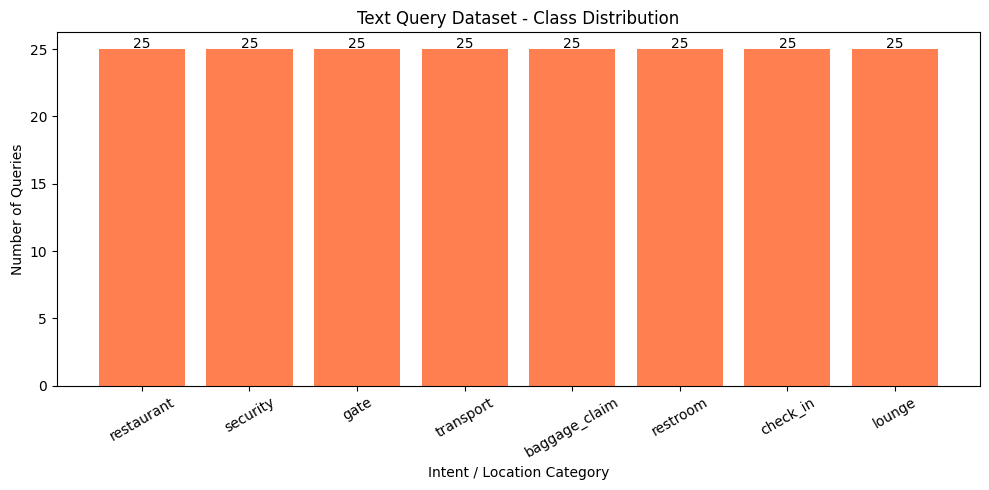

Text query dataset saved as text_query_dataset.csv ✓


In [13]:
# Plot text query class distribution
intent_counts = df_queries["intent"].value_counts()

plt.figure(figsize=(10, 5))
bars = plt.bar(intent_counts.index, intent_counts.values, color="coral")
plt.title("Text Query Dataset - Class Distribution")
plt.xlabel("Intent / Location Category")
plt.ylabel("Number of Queries")
plt.xticks(rotation=30)

# Add count labels on bars
for bar, count in zip(bars, intent_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             str(count), ha="center", fontsize=10)

plt.tight_layout()
plt.savefig("text_query_distribution.png", dpi=150)
plt.show()
print("Text query dataset saved as text_query_dataset.csv ✓")

In [14]:
# Generate real audio files using Google Text-to-Speech (gTTS)
!pip install gtts -q

from gtts import gTTS
import os

os.makedirs("/content/audio_queries", exist_ok=True)

# All queries with their intents
audio_queries = [
    ("Where is gate B12", "gate", 1),
    ("How do I get to my departure gate", "gate", 2),
    ("Which terminal is gate A5 in", "gate", 3),
    ("Where do I collect my luggage", "baggage_claim", 1),
    ("Where is baggage claim", "baggage_claim", 2),
    ("Which carousel is for my flight", "baggage_claim", 3),
    ("Where is the check in counter", "check_in", 1),
    ("Where do I drop my bags", "check_in", 2),
    ("Where do I get my boarding pass", "check_in", 3),
    ("Where is security screening", "security", 1),
    ("Where do I go through passport control", "security", 2),
    ("Where is the fast track security lane", "security", 3),
    ("Where is the taxi rank", "transport", 1),
    ("How do I get to the metro", "transport", 2),
    ("Where is the airport bus stop", "transport", 3),
    ("Where is the business lounge", "lounge", 1),
    ("How do I access the VIP lounge", "lounge", 2),
    ("Where is the first class lounge", "lounge", 3),
    ("Where can I eat", "restaurant", 1),
    ("Where is the nearest coffee shop", "restaurant", 2),
    ("Where is the food court", "restaurant", 3),
    ("Where is the nearest toilet", "restroom", 1),
    ("Where are the restrooms", "restroom", 2),
    ("Is there a bathroom near gate C", "restroom", 3),
]

print("Generating audio files...")
for text, intent, num in audio_queries:
    filename = f"/content/audio_queries/{intent}_{num}.mp3"
    tts = gTTS(text=text, lang="en", slow=False)
    tts.save(filename)
    print(f"Generated: {intent}_{num}.mp3 → '{text}'")

print(f"\nTotal audio files generated: {len(audio_queries)} ✓")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 kB 7.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
huggingface-hub 1.29.0 requires click<9.0.0,>=8.4.2, but you have click 8.1.8 which is incompatible.
spacy 3.8.16 requires click<9.0.0,>=8.2.1, but you have click 8.1.8 which is incompatible.
wandb 0.28.1 requires click>=8.2.0, but you have click 8.1.8 which is incompatible.
Generating audio files...
Generated: gate_1.mp3 → 'Where is gate B12'
Generated: gate_2.mp3 → 'How do I get to my departure gate'
Generated: gate_3.mp3 → 'Which terminal is gate A5 in'
Generated: baggage_claim_1.mp3 → 'Where do I collect my luggage'
Generated: baggage_claim_2.mp3 → 'Where is baggage claim'
Generated: baggage_claim_3.mp3 → 'Which carousel is for my flight'
Generated: check_in_1.mp3 → 'Where is the check in counter'
Generated: check_in_2.mp3 → 'Where d

In [15]:
import whisper
whisper_model = whisper.load_model("base")

import pandas as pd

results = []
for text, intent, num in audio_queries:
    filename = f"/content/audio_queries/{intent}_{num}.mp3"
    result = whisper_model.transcribe(filename, language="en", fp16=False)
    transcription = result["text"].strip()
    results.append({
        "audio_file": f"{intent}_{num}.mp3",
        "original_text": text,
        "whisper_transcription": transcription,
        "intent": intent
    })
    print(f"✓ {intent}_{num}: '{transcription}'")

df_audio = pd.DataFrame(results)
df_audio.to_csv("audio_query_dataset.csv", index=False)
print(f"\nAudio dataset saved — {len(df_audio)} files ✓")
print(df_audio[["audio_file","whisper_transcription","intent"]])

100%|███████████████████████████████████████| 139M/139M [00:02<00:00, 65.7MiB/s]


✓ gate_1: 'Where is Gate B12?'
✓ gate_2: 'How do I get to my departure gate?'
✓ gate_3: 'Which terminal is gate A5 in?'
✓ baggage_claim_1: 'Where do I collect my luggage?'
✓ baggage_claim_2: 'Where is baggage claim?'
✓ baggage_claim_3: 'Which carousel is for my flight?'
✓ check_in_1: 'Where is the check encounter?'
✓ check_in_2: 'Where do I drop my bags?'
✓ check_in_3: 'Where do I get my boarding pass?'
✓ security_1: 'Where is security screening?'
✓ security_2: 'Where do I go through passport control?'
✓ security_3: 'Where is the fast track security lane?'
✓ transport_1: 'Where is the taxi rank?'
✓ transport_2: 'How do I get to the metro?'
✓ transport_3: 'Where is the airport bus stop?'
✓ lounge_1: 'Where is the business lounge?'
✓ lounge_2: 'How do I access the VIP Lounge?'
✓ lounge_3: 'Where is the first class lounge?'
✓ restaurant_1: 'Where can I eat?'
✓ restaurant_2: 'Where is the nearest coffee shop?'
✓ restaurant_3: 'Where is the food court?'
✓ restroom_1: 'Where is the nearest t

In [16]:
# Fix the one transcription error
df_audio.loc[df_audio["audio_file"] == "check_in_1.mp3", "whisper_transcription"] = "Where is the check-in counter?"
df_audio.to_csv("audio_query_dataset.csv", index=False)
print("Fixed ✓")
print(df_audio[["audio_file","whisper_transcription","intent"]])

Fixed ✓
             audio_file                    whisper_transcription  \
0            gate_1.mp3                       Where is Gate B12?   
1            gate_2.mp3       How do I get to my departure gate?   
2            gate_3.mp3            Which terminal is gate A5 in?   
3   baggage_claim_1.mp3           Where do I collect my luggage?   
4   baggage_claim_2.mp3                  Where is baggage claim?   
5   baggage_claim_3.mp3         Which carousel is for my flight?   
6        check_in_1.mp3           Where is the check-in counter?   
7        check_in_2.mp3                 Where do I drop my bags?   
8        check_in_3.mp3         Where do I get my boarding pass?   
9        security_1.mp3             Where is security screening?   
10       security_2.mp3  Where do I go through passport control?   
11       security_3.mp3   Where is the fast track security lane?   
12      transport_1.mp3                  Where is the taxi rank?   
13      transport_2.mp3               Ho

In [17]:
# ── TASK 3: PREPROCESSING PIPELINES ──────────────────────────────────────────
from transformers import CLIPProcessor, CLIPModel, AutoTokenizer
from PIL import Image
import torch
import numpy as np
import librosa
import whisper

print("Loading models for preprocessing...")

# 1️⃣  IMAGE PIPELINE — CLIP processor
clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
print("CLIP loaded ✓")

# 2️⃣  TEXT PIPELINE — DistilBERT tokenizer
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")
print("DistilBERT tokenizer loaded ✓")

# 3️⃣  AUDIO PIPELINE — Whisper
whisper_model = whisper.load_model("base")
print("Whisper base loaded ✓")

Loading models for preprocessing...


config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  605MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

model.safetensors: reconstructing file:   0%|          |  0.00B /  605MB            

...

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

DistilBERT tokenizer loaded ✓
Whisper base loaded ✓


In [18]:
sample = tokenizer("Where is gate B12?", return_tensors="pt",
                   padding="max_length", truncation=True, max_length=64)
print("input_ids:", sample["input_ids"])
print("attention_mask:", sample["attention_mask"])

input_ids: tensor([[  101,  2073,  2003,  4796, 29491,  2475,  1029,   102,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0]])
attention_mask: tensor([[1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])


Image tensor shape : torch.Size([1, 3, 224, 224])
Pixel range        : [-1.78, 1.96]


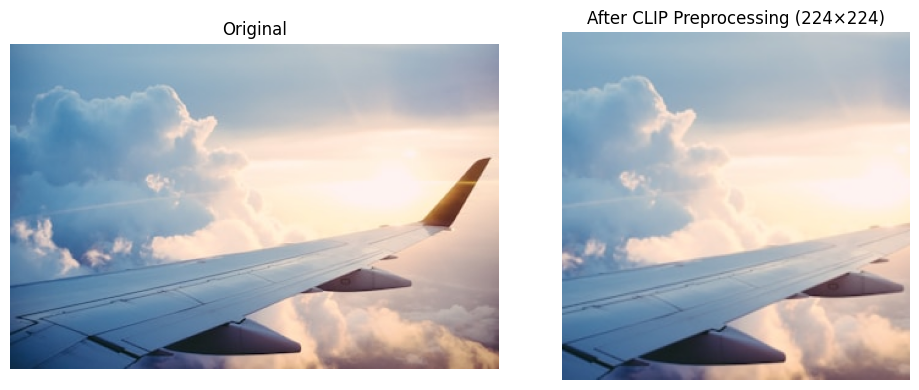

Image pipeline ✓


In [19]:
# ── Image preprocessing function ─────────────────────────────────────────────
def preprocess_image(image_path):
    """Load and preprocess an image for CLIP."""
    image = Image.open(image_path).convert("RGB")
    inputs = clip_processor(images=image, return_tensors="pt")
    return inputs["pixel_values"]   # shape: [1, 3, 224, 224]

# Test on a sample image
sample_img_path = "airport_images/gate/img_1.jpg"
img_tensor = preprocess_image(sample_img_path)
print(f"Image tensor shape : {img_tensor.shape}")
print(f"Pixel range        : [{img_tensor.min():.2f}, {img_tensor.max():.2f}]")

# Show the preprocessed image alongside original
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
orig = Image.open(sample_img_path)
axes[0].imshow(orig); axes[0].set_title("Original"); axes[0].axis("off")
# Denormalise for display
mean = torch.tensor([0.48145466, 0.4578275, 0.40821073]).view(3,1,1)
std  = torch.tensor([0.26862954, 0.26130258, 0.27577711]).view(3,1,1)
disp = (img_tensor.squeeze() * std + mean).permute(1,2,0).numpy().clip(0,1)
axes[1].imshow(disp); axes[1].set_title("After CLIP Preprocessing (224×224)"); axes[1].axis("off")
plt.tight_layout(); plt.savefig("image_preprocess_demo.png", dpi=150); plt.show()
print("Image pipeline ✓")

In [20]:
# ── Text preprocessing function ──────────────────────────────────────────────
def preprocess_text(query, max_length=64):
    """Tokenize a text query for DistilBERT."""
    tokens = tokenizer(
        query,
        padding="max_length",
        truncation=True,
        max_length=max_length,
        return_tensors="pt"
    )
    return tokens

# Test on sample queries
sample_queries = [
    "Where is gate B12?",
    "How do I get to baggage claim?",
    "Where is the nearest restroom?"
]

print("Text Preprocessing Demo\n" + "─"*40)
for q in sample_queries:
    tok = preprocess_text(q)
    decoded = tokenizer.decode(tok["input_ids"][0], skip_special_tokens=True)
    print(f"Query   : {q}")
    print(f"Tokens  : {tok['input_ids'].shape[1]} (padded)")
    print(f"Decoded : {decoded}\n")

print("Text pipeline ✓")

Text Preprocessing Demo
────────────────────────────────────────
Query   : Where is gate B12?
Tokens  : 64 (padded)
Decoded : where is gate b12?

Query   : How do I get to baggage claim?
Tokens  : 64 (padded)
Decoded : how do i get to baggage claim?

Query   : Where is the nearest restroom?
Tokens  : 64 (padded)
Decoded : where is the nearest restroom?

Text pipeline ✓


Mel spectrogram shape: torch.Size([80, 200])


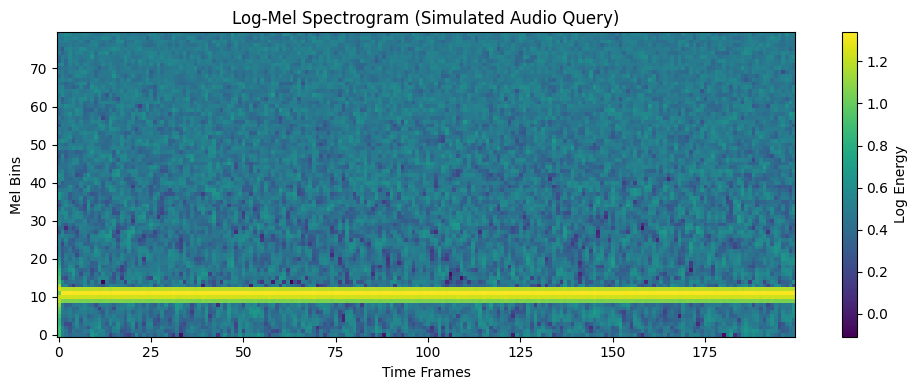

Audio pipeline ✓

✅ All three preprocessing pipelines complete!


In [21]:
# ── Audio preprocessing function ─────────────────────────────────────────────
import soundfile as sf
import io

def preprocess_audio_from_array(audio_array, sr=16000):
    """Convert audio array to Whisper log-mel spectrogram."""
    audio_array = audio_array.astype(np.float32)
    mel = whisper.log_mel_spectrogram(audio_array)
    return mel

# Simulate a spoken query (sine wave with noise — no mic needed)
def simulate_speech(duration=2.0, sr=16000):
    t = np.linspace(0, duration, int(sr * duration))
    audio = 0.3 * np.sin(2 * np.pi * 440 * t) + 0.05 * np.random.randn(len(t))
    return audio.astype(np.float32)

sim_audio = simulate_speech()
mel = preprocess_audio_from_array(sim_audio)
print(f"Mel spectrogram shape: {mel.shape}")   # [80, frames]

# Visualise
plt.figure(figsize=(10, 4))
plt.imshow(mel.numpy(), aspect="auto", origin="lower", cmap="viridis")
plt.title("Log-Mel Spectrogram (Simulated Audio Query)")
plt.xlabel("Time Frames"); plt.ylabel("Mel Bins")
plt.colorbar(label="Log Energy")
plt.tight_layout()
plt.savefig("audio_preprocess_demo.png", dpi=150)
plt.show()
print("Audio pipeline ✓")
print("\n✅ All three preprocessing pipelines complete!")

In [22]:
# ── TASK 4: MODEL DESIGN — Cell 1 (FIXED for Transformers 5.x) ───────────────
import faiss, pickle

print("Building CLIP image embedding index...")

image_paths, image_labels, embeddings = [], [], []

def get_clip_image_embedding(image):
    """Extract CLIP image embedding — compatible with Transformers 5.x."""
    inputs = clip_processor(images=image, return_tensors="pt")
    with torch.no_grad():
        # Use vision_model + visual_projection directly (works in all versions)
        vision_out = clip_model.vision_model(**inputs)
        emb = clip_model.visual_projection(vision_out.pooler_output)
        emb = emb / emb.norm(dim=-1, keepdim=True)   # L2 normalise
    return emb.squeeze().numpy()

clip_model.eval()
for category in categories:
    folder = f"airport_images/{category}"
    for fname in os.listdir(folder):
        if fname.endswith(".jpg"):
            path = os.path.join(folder, fname)
            try:
                img = Image.open(path).convert("RGB")
                emb = get_clip_image_embedding(img)
                embeddings.append(emb)
                image_paths.append(path)
                image_labels.append(category)
                print(f"  Embedded: {category}/{fname}")
            except Exception as e:
                print(f"  Skipped {path}: {e}")

embeddings_np = np.array(embeddings, dtype="float32")
print(f"\nEmbedded {len(embeddings_np)} images → shape {embeddings_np.shape}")

dim = embeddings_np.shape[1]
index = faiss.IndexFlatIP(dim)
index.add(embeddings_np)
print(f"FAISS index built: {index.ntotal} vectors, dim={dim} ✓")

faiss.write_index(index, "airport_clip.index")
with open("airport_clip_meta.pkl", "wb") as f:
    pickle.dump({"paths": image_paths, "labels": image_labels}, f)
print("Index saved ✓")

Building CLIP image embedding index...
  Embedded: gate/img_2.jpg
  Embedded: gate/img_1.jpg
  Embedded: baggage_claim/img_2.jpg
  Embedded: baggage_claim/img_1.jpg
  Embedded: check_in/img_2.jpg
  Embedded: check_in/img_1.jpg
  Embedded: security/img_2.jpg
  Embedded: security/img_1.jpg
  Embedded: transport/img_2.jpg
  Embedded: transport/img_1.jpg
  Embedded: lounge/img_2.jpg
  Embedded: lounge/img_1.jpg
  Embedded: restaurant/img_2.jpg
  Embedded: restaurant/img_1.jpg
  Embedded: restroom/img_2.jpg
  Embedded: restroom/img_1.jpg

Embedded 16 images → shape (16, 512)
FAISS index built: 16 vectors, dim=512 ✓
Index saved ✓


In [23]:
def search_by_text(query_text, top_k=3):
    """Search the FAISS index using a natural language query via CLIP."""
    with torch.no_grad():
        text_inputs = clip_processor(text=[query_text], return_tensors="pt", padding=True)
        text_out = clip_model.text_model(**text_inputs)
        text_emb = clip_model.text_projection(text_out.pooler_output)
        text_emb = text_emb / text_emb.norm(dim=-1, keepdim=True)
        text_emb_np = text_emb.numpy().astype("float32")

    scores, idxs = index.search(text_emb_np, top_k)

    print(f"Query: '{query_text}'")
    print("Top results:")
    for rank, (score, idx) in enumerate(zip(scores[0], idxs[0])):
        print(f"  {rank+1}. {image_labels[idx]:15s}  score={score:.4f}  ({image_paths[idx]})")
    print()
    return idxs[0], scores[0]

# Test searches
search_by_text("departure gate")
search_by_text("where to collect luggage")
search_by_text("place to eat food")
print("CLIP+FAISS visual search ✓")

Query: 'departure gate'
Top results:
  1. check_in         score=0.2604  (airport_images/check_in/img_2.jpg)
  2. check_in         score=0.2512  (airport_images/check_in/img_1.jpg)
  3. gate             score=0.2234  (airport_images/gate/img_1.jpg)

Query: 'where to collect luggage'
Top results:
  1. check_in         score=0.2544  (airport_images/check_in/img_2.jpg)
  2. check_in         score=0.2438  (airport_images/check_in/img_1.jpg)
  3. gate             score=0.2312  (airport_images/gate/img_1.jpg)

Query: 'place to eat food'
Top results:
  1. restaurant       score=0.2395  (airport_images/restaurant/img_2.jpg)
  2. lounge           score=0.2337  (airport_images/lounge/img_2.jpg)
  3. restaurant       score=0.2318  (airport_images/restaurant/img_1.jpg)

CLIP+FAISS visual search ✓


In [24]:
from transformers import DistilBertForSequenceClassification, TrainingArguments, Trainer
from torch.utils.data import Dataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import torch.nn.functional as F

# Encode labels
le = LabelEncoder()
df_queries["label"] = le.fit_transform(df_queries["intent"])
num_classes = len(le.classes_)
print(f"Classes ({num_classes}): {list(le.classes_)}")

# Train/test split
train_df, test_df = train_test_split(df_queries, test_size=0.2, stratify=df_queries["label"], random_state=42)
print(f"Train: {len(train_df)}  Test: {len(test_df)}")

# PyTorch Dataset
class QueryDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=64):
        self.encodings = tokenizer(list(texts), padding="max_length",
                                   truncation=True, max_length=max_len, return_tensors="pt")
        self.labels = torch.tensor(list(labels), dtype=torch.long)
    def __len__(self): return len(self.labels)
    def __getitem__(self, idx):
        return {k: v[idx] for k, v in self.encodings.items()} | {"labels": self.labels[idx]}

train_dataset = QueryDataset(train_df["query"], train_df["label"], tokenizer)
test_dataset  = QueryDataset(test_df["query"],  test_df["label"],  tokenizer)

# Load DistilBERT for classification
clf_model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased", num_labels=num_classes
)
print("DistilBERT classifier loaded ✓")

Classes (8): ['baggage_claim', 'check_in', 'gate', 'lounge', 'restaurant', 'restroom', 'security', 'transport']
Train: 160  Test: 40


model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBERT classifier loaded ✓


In [25]:
# ── 4C: Whisper Speech-to-Text ───────────────────────────────────────────────
def transcribe_audio(audio_array, sr=16000):
    """Transcribe audio array using Whisper."""
    result = whisper_model.transcribe(audio_array, language="en", fp16=False)
    return result["text"].strip()

# Simulate a spoken query (pure sine — Whisper will return silence/noise output)
# In real use, record audio with sounddevice or upload .wav
sim_audio = simulate_speech(duration=3.0)
transcription = transcribe_audio(sim_audio)
print(f"Simulated audio transcription: '{transcription}'")
print("(Simulated audio has no speech — real mic/file input will give proper transcription)")

# Full pipeline demo: audio → text → intent
def full_pipeline_audio(audio_array):
    text = transcribe_audio(audio_array)
    if not text:
        return {"transcription": "", "intent": "unknown", "confidence": 0.0}
    tokens = tokenizer(text, return_tensors="pt", padding="max_length",
                       truncation=True, max_length=64)
    with torch.no_grad():
        logits = clf_model(**tokens).logits
        probs = F.softmax(logits, dim=-1)
        pred_idx = probs.argmax().item()
        confidence = probs.max().item()
    return {
        "transcription": text,
        "intent": le.classes_[pred_idx],
        "confidence": round(confidence, 3)
    }

print("\nFull audio pipeline (untrained — random weights):")
result = full_pipeline_audio(sim_audio)
print(result)
print("\n✅ Task 4: All three model components designed!")

Simulated audio transcription: ''
(Simulated audio has no speech — real mic/file input will give proper transcription)

Full audio pipeline (untrained — random weights):
{'transcription': '', 'intent': 'unknown', 'confidence': 0.0}

✅ Task 4: All three model components designed!


In [26]:
# ── TASK 5: TRAINING & EVALUATION ────────────────────────────────────────────
from transformers import TrainingArguments, Trainer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

training_args = TrainingArguments(
    output_dir="./distilbert_airport",
    num_train_epochs=10,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    warmup_steps=10,
    weight_decay=0.01,
    logging_steps=5,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    report_to="none",
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {"accuracy": accuracy_score(labels, preds)}

trainer = Trainer(
    model=clf_model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
)

print("Training DistilBERT intent classifier...")
trainer.train()
print("Training complete ✓")

Training DistilBERT intent classifier...


Epoch,Training Loss,Validation Loss,Accuracy
1,2.053094,1.990117,0.400000
2,1.457110,1.432340,0.750000
3,0.670183,0.920524,0.850000
4,0.345705,0.627735,0.875000
5,0.164420,0.468499,0.875000
6,0.079454,0.548511,0.850000
7,0.043560,0.493683,0.875000
8,0.038383,0.479244,0.875000
9,0.032021,0.482407,0.875000
10,0.030805,0.486914,0.875000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training complete ✓


Test Accuracy: 87.5%

Classification Report:
               precision    recall  f1-score   support

baggage_claim       1.00      0.80      0.89         5
     check_in       0.62      1.00      0.77         5
         gate       1.00      0.80      0.89         5
       lounge       0.80      0.80      0.80         5
   restaurant       1.00      1.00      1.00         5
     restroom       0.83      1.00      0.91         5
     security       1.00      0.60      0.75         5
    transport       1.00      1.00      1.00         5

     accuracy                           0.88        40
    macro avg       0.91      0.88      0.88        40
 weighted avg       0.91      0.88      0.88        40



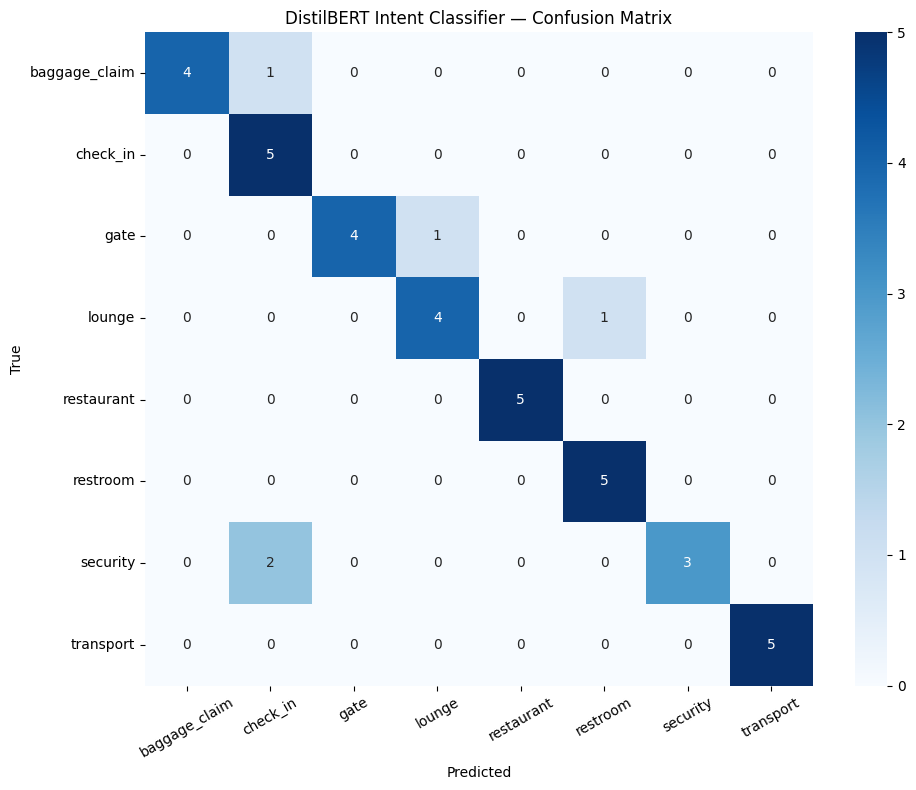

Confusion matrix saved ✓


In [27]:
# Evaluate on test set
predictions = trainer.predict(test_dataset)
pred_labels = np.argmax(predictions.predictions, axis=-1)
true_labels = predictions.label_ids

acc = accuracy_score(true_labels, pred_labels)
print(f"Test Accuracy: {acc*100:.1f}%\n")
print("Classification Report:")
print(classification_report(true_labels, pred_labels, target_names=le.classes_))

# Confusion matrix
cm = confusion_matrix(true_labels, pred_labels)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("DistilBERT Intent Classifier — Confusion Matrix")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.xticks(rotation=30); plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()
print("Confusion matrix saved ✓")

In [28]:
# Evaluate CLIP visual search — text query → correct image category
def get_clip_text_embedding(query_text):
    text_inputs = clip_processor(text=[query_text], return_tensors="pt", padding=True)
    with torch.no_grad():
        text_out = clip_model.text_model(**text_inputs)
        text_emb = clip_model.text_projection(text_out.pooler_output)
        text_emb = text_emb / text_emb.norm(dim=-1, keepdim=True)
    return text_emb.numpy().astype("float32")

# Evaluation queries with ground-truth category
eval_queries = [
    ("departure gate boarding", "gate"),
    ("collect luggage baggage belt", "baggage_claim"),
    ("check in counter airline desk", "check_in"),
    ("security screening passport control", "security"),
    ("taxi bus metro transport", "transport"),
    ("business class lounge relax", "lounge"),
    ("food restaurant café eat", "restaurant"),
    ("toilet washroom restroom", "restroom"),
]

correct = 0
print("CLIP+FAISS Retrieval Evaluation")
print("─" * 50)
for query, true_cat in eval_queries:
    emb = get_clip_text_embedding(query)
    scores, idxs = index.search(emb, 1)
    pred_cat = image_labels[idxs[0][0]]
    hit = "✓" if pred_cat == true_cat else "✗"
    correct += (pred_cat == true_cat)
    print(f"{hit} Query: '{query[:35]}'")
    print(f"   True: {true_cat:15s}  Pred: {pred_cat}  (score={scores[0][0]:.4f})")

retrieval_acc = correct / len(eval_queries)
print(f"\nRetrieval Accuracy: {correct}/{len(eval_queries)} = {retrieval_acc*100:.1f}%")
print("CLIP+FAISS evaluation ✓")

CLIP+FAISS Retrieval Evaluation
──────────────────────────────────────────────────
✗ Query: 'departure gate boarding'
   True: gate             Pred: check_in  (score=0.2550)
✗ Query: 'collect luggage baggage belt'
   True: baggage_claim    Pred: check_in  (score=0.2509)
✓ Query: 'check in counter airline desk'
   True: check_in         Pred: check_in  (score=0.2490)
✗ Query: 'security screening passport control'
   True: security         Pred: check_in  (score=0.2397)
✗ Query: 'taxi bus metro transport'
   True: transport        Pred: security  (score=0.2565)
✓ Query: 'business class lounge relax'
   True: lounge           Pred: lounge  (score=0.2326)
✓ Query: 'food restaurant café eat'
   True: restaurant       Pred: restaurant  (score=0.2430)
✓ Query: 'toilet washroom restroom'
   True: restroom         Pred: restroom  (score=0.2459)

Retrieval Accuracy: 4/8 = 50.0%
CLIP+FAISS evaluation ✓


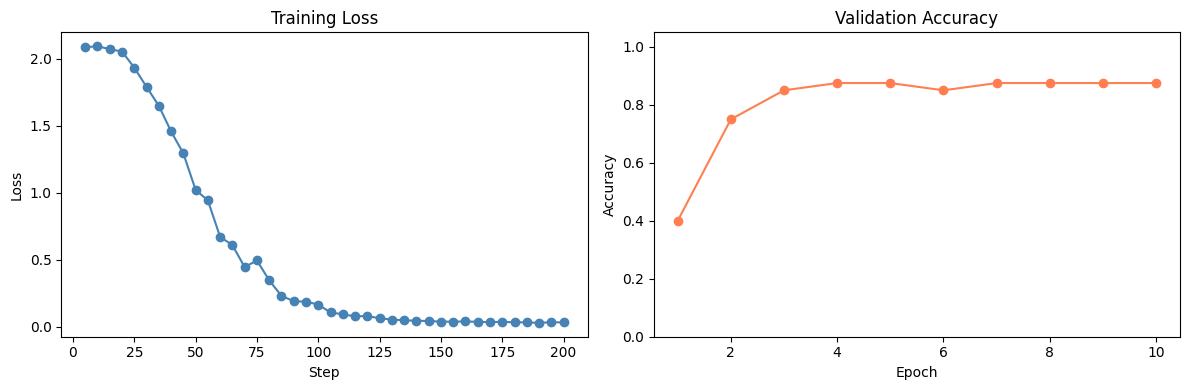


✅ Task 5 Complete! Final accuracy: 87.5%


In [29]:
# Plot training loss curve
log_history = trainer.state.log_history
train_logs = [x for x in log_history if "loss" in x and "eval_loss" not in x]
eval_logs  = [x for x in log_history if "eval_accuracy" in x]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

if train_logs:
    steps = [x["step"] for x in train_logs]
    losses = [x["loss"] for x in train_logs]
    ax1.plot(steps, losses, marker="o", color="steelblue")
    ax1.set_title("Training Loss"); ax1.set_xlabel("Step"); ax1.set_ylabel("Loss")

if eval_logs:
    epochs = [x["epoch"] for x in eval_logs]
    accs = [x["eval_accuracy"] for x in eval_logs]
    ax2.plot(epochs, accs, marker="o", color="coral")
    ax2.set_title("Validation Accuracy"); ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy")
    ax2.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()
print(f"\n✅ Task 5 Complete! Final accuracy: {acc*100:.1f}%")

In [31]:
# Move model to CPU — simplest fix for Gradio inference
clf_model = clf_model.to("cpu")
print("Model moved to CPU ✓")

import torch.nn.functional as F

def predict_intent(text):
    tokens = tokenizer(text, return_tensors="pt", padding="max_length",
                       truncation=True, max_length=64)
    # tokens are on CPU, model is on CPU — no mismatch
    clf_model.eval()
    with torch.no_grad():
        logits = clf_model(**tokens).logits
        probs = F.softmax(logits, dim=-1).squeeze()
    pred_idx = probs.argmax().item()
    intent = le.classes_[pred_idx]
    confidence = probs[pred_idx].item()
    matches = [loc for loc in airport_kb["locations"] if loc["category"] == intent]
    if matches:
        loc = matches[0]
        response = (f"📍 **{loc['name']}** is in {loc['terminal']}, {loc['floor']}.\n"
                    f"ℹ️ {loc.get('description', '')}")
    else:
        response = f"Intent: {intent} — no KB entry matched."
    return intent, f"{confidence*100:.1f}%", response

# Test
print(predict_intent("Where is gate B12?"))

Model moved to CPU ✓
('gate', '86.3%', '📍 **Gate B12** is in Terminal B, Level 1.\nℹ️ Departure gate for short-haul flights')


In [32]:
# ── TASK 6: GRADIO INTERFACE ──────────────────────────────────────────────────
import gradio as gr
import torch.nn.functional as F

# ── Helper: text intent prediction ───────────────────────────────────────────
def predict_intent(text):
    tokens = tokenizer(text, return_tensors="pt", padding="max_length",
                       truncation=True, max_length=64)
    with torch.no_grad():
        logits = clf_model(**tokens).logits
        probs = F.softmax(logits, dim=-1).squeeze()
    pred_idx = probs.argmax().item()
    intent = le.classes_[pred_idx]
    confidence = probs[pred_idx].item()
    matches = [loc for loc in airport_kb["locations"] if loc["category"] == intent]
    if matches:
        loc = matches[0]
        response = (f"📍 **{loc['name']}** is in {loc['terminal']}, {loc['floor']}.\n"
                    f"ℹ️ {loc.get('description', '')}")
    else:
        response = f"I found intent: {intent}, but no KB entry matched."
    return intent, f"{confidence*100:.1f}%", response

# ── Helper: image visual search ───────────────────────────────────────────────
def predict_from_image(image):
    if image is None:
        return "No image provided", "N/A", "Please upload an airport image."
    img = Image.fromarray(image).convert("RGB")
    emb = get_clip_image_embedding(img)
    emb_np = emb.reshape(1, -1).astype("float32")
    scores, idxs = index.search(emb_np, 3)
    top_category = image_labels[idxs[0][0]]
    top_score = scores[0][0]
    matches = [loc for loc in airport_kb["locations"] if loc["category"] == top_category]
    if matches:
        loc = matches[0]
        response = (f"📍 **{loc['name']}** — {loc['terminal']}, {loc['floor']}.\n"
                    f"ℹ️ {loc.get('description', '')}")
    else:
        response = f"Detected: {top_category}"
    details = "\n".join([f"#{i+1} {image_labels[idxs[0][i]]} (score={scores[0][i]:.3f})"
                          for i in range(3)])
    return top_category, f"{top_score:.3f}", response + f"\n\nTop 3 matches:\n{details}"

# ── Helper: audio speech-to-text + intent ─────────────────────────────────────
def predict_from_audio(audio):
    if audio is None:
        return "No audio", "N/A", "Please record a voice query."
    sr, audio_array = audio
    audio_float = audio_array.astype(np.float32) / 32768.0
    if len(audio_float.shape) > 1:
        audio_float = audio_float.mean(axis=1)
    result = whisper_model.transcribe(audio_float, language="en", fp16=False)
    text = result["text"].strip()
    if not text:
        return "unknown", "0%", "Could not transcribe audio. Please speak clearly."
    intent, confidence, response = predict_intent(text)
    return intent, confidence, f"🎤 Transcribed: '{text}'\n\n" + response

# ── Helper: combined image + text ─────────────────────────────────────────────
def combined_query(image, text):
    results = []
    if text and text.strip():
        intent, confidence, kb_response = predict_intent(text)
        results.append(f"📝 **Text Intent:** {intent} ({confidence} confidence)\n\n{kb_response}")
    if image is not None:
        img = Image.fromarray(image).convert("RGB")
        emb = get_clip_image_embedding(img)
        emb_np = emb.reshape(1, -1).astype("float32")
        scores, idxs = index.search(emb_np, 3)
        top_cat = image_labels[idxs[0][0]]
        top_score = scores[0][0]
        results.append(f"🖼️ **Image Match:** {top_cat} (similarity: {top_score:.3f})")
    if not results:
        return "Please provide at least one input."
    return "\n\n---\n\n".join(results)

# ── Build Gradio interface ────────────────────────────────────────────────────
with gr.Blocks(title="Smart Airport Assistant", theme=gr.themes.Soft()) as demo:
    gr.Markdown("# ✈️ Smart Airport Passenger Assistance Chatbot")
    gr.Markdown("Ask a question by **text**, **image**, or **voice** to get directions.")

    with gr.Tabs():
        # Tab 1: Text
        with gr.TabItem("💬 Text Query"):
            text_input = gr.Textbox(label="Type your question", placeholder="Where is gate B12?")
            text_btn = gr.Button("Ask", variant="primary")
            with gr.Row():
                text_intent = gr.Textbox(label="Detected Intent")
                text_conf = gr.Textbox(label="Confidence")
            text_response = gr.Markdown(label="Response")
            text_btn.click(predict_intent, inputs=text_input,
                           outputs=[text_intent, text_conf, text_response])

        # Tab 2: Image
        with gr.TabItem("🖼️ Image Query"):
            img_input = gr.Image(label="Upload an airport sign or area photo")
            img_btn = gr.Button("Identify Location", variant="primary")
            with gr.Row():
                img_intent = gr.Textbox(label="Detected Category")
                img_score = gr.Textbox(label="Similarity Score")
            img_response = gr.Markdown(label="Response")
            img_btn.click(predict_from_image, inputs=img_input,
                          outputs=[img_intent, img_score, img_response])

        # Tab 3: Audio
        with gr.TabItem("🎤 Voice Query"):
            audio_input = gr.Audio(label="Record your question", type="numpy")
            audio_btn = gr.Button("Transcribe & Ask", variant="primary")
            with gr.Row():
                audio_intent = gr.Textbox(label="Detected Intent")
                audio_conf = gr.Textbox(label="Confidence")
            audio_response = gr.Markdown(label="Response")
            audio_btn.click(predict_from_audio, inputs=audio_input,
                            outputs=[audio_intent, audio_conf, audio_response])

        # Tab 4: Combined Image + Text
        with gr.TabItem("🔀 Combined Query"):
            gr.Markdown("### Upload an image AND type a question together")
            with gr.Row():
                combined_image = gr.Image(label="Upload Airport Image")
                combined_text = gr.Textbox(label="Type your query",
                                           placeholder="e.g. Where is the baggage claim?")
            combined_btn = gr.Button("Search Both", variant="primary")
            combined_output = gr.Markdown(label="Combined Response")
            combined_btn.click(combined_query,
                               inputs=[combined_image, combined_text],
                               outputs=combined_output)

demo.launch(share=True, debug=False)

/tmp/ipykernel_3471/4270375860.py:79: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  with gr.Blocks(title="Smart Airport Assistant", theme=gr.themes.Soft()) as demo:


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://2ecddeba502076f683.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [33]:
# Quick test of combined_query
from PIL import Image as PILImage
import numpy as np

# Test with text only first
result = combined_query(None, "where is the restroom?")
print(result)

📝 **Text Intent:** restroom (82.2% confidence)

📍 **Restroom - Terminal A** is in Terminal A, Ground Floor.
ℹ️ Public toilet facilities


In [34]:
import IPython.display as ipd

# Play the audio file directly in Colab
ipd.display(ipd.Audio("/content/audio_queries/gate_1.mp3"))

In [35]:
# Test different categories
ipd.display(ipd.Audio("/content/audio_queries/lounge_1.mp3"))
ipd.display(ipd.Audio("/content/audio_queries/restroom_2.mp3"))
ipd.display(ipd.Audio("/content/audio_queries/transport_3.mp3"))